## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [5]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1004464 entries, 0 to 1004463
,Data columns (total 12 columns):
, #   Column                          Non-Null Count    Dtype  
,---  ------                          --------------    -----  
, 0   Country                         1004464 non-null  object 
, 1   City                            1004464 non-null  object 
, 2   UpdateTimeUTC                   1004464 non-null  object 
, 3   JamsDelay                       1004464 non-null  float64
, 4   TrafficIndexLive                1004464 non-null  float64
, 5   JamsLengthInKms                 1004464 non-null  float64
, 6   JamsCount                       1004464 non-null  float64
, 7   TrafficIndexWeekAgo             1004464 non-null  float64
, 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
, 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
, 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
, 11  MinsDelay                       1004464 non-nul

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo 'object'

In [6]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 30 entries, 0 to 29
,Data columns (total 7 columns):
, #   Column           Non-Null Count  Dtype 
,---  ------           --------------  ----- 
, 0   Year             30 non-null     int64 
, 1   City             30 non-null     object
, 2   Country          30 non-null     object
, 3   City GDP/capita  30 non-null     object
, 4   Unemployment %   30 non-null     object
, 5   PM2.5 (μg/m³)    30 non-null     object
, 6   Population (M)   30 non-null     object
,dtypes: int64(1), object(6)
,memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, 'Year' son del tipo incorrecto 

In [7]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={'City':'city','Country':'country','UpdateTimeUTC':'update_time_utc','UpdateTimeUTCWeekAgo':'update_time_utc_week_ago','JamsDelay':'jams_delay','TrafficIndexLive':'traffic_index_live', 'JamsLengthInKms':'jams_length_kms','JamsCount':'jams_count','TrafficIndexWeekAgo':'traffic_index_week_ago','TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins','TravelTimeHistoricPer10KmsMins':'travel_time_hist_per_10kms_mins','MinsDelay':'mins_delay'})

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={'City':'city','Country':'country','City GDP/capita':'city_gdp_capita','Unemployment %':'unemployment_pct','Population (M)':'population_m','Year':'year','PM2.5 (μg/m³)':'pm25'})

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])#tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])#tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1004464 entries, 0 to 1004463
,Data columns (total 12 columns):
, #   Column                           Non-Null Count    Dtype         
,---  ------                           --------------    -----         
, 0   country                          1004464 non-null  object        
, 1   city                             1004464 non-null  object        
, 2   update_time_utc                  1004464 non-null  datetime64[ns]
, 3   jams_delay                       1004464 non-null  float64       
, 4   traffic_index_live               1004464 non-null  float64       
, 5   jams_length_kms                  1004464 non-null  float64       
, 6   jams_count                       1004464 non-null  float64       
, 7   traffic_index_week_ago           1004464 non-null  float64       
, 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
, 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
, 10  travel_time_his

In [10]:

# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '',regex=False).str.replace(',', '.',regex=False).astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace("%", "", regex=False).str.replace('.', '',regex=False).str.replace(',', '.',regex=False).astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = (eco['population_m'] * 1000000)


# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 30 entries, 0 to 29
,Data columns (total 8 columns):
, #   Column            Non-Null Count  Dtype  
,---  ------            --------------  -----  
, 0   year              30 non-null     int64  
, 1   city              30 non-null     object 
, 2   country           30 non-null     object 
, 3   city_gdp_capita   30 non-null     float64
, 4   unemployment_pct  30 non-null     float64
, 5   pm25              30 non-null     object 
, 6   population_m      30 non-null     float64
, 7   population        30 non-null     float64
,dtypes: float64(4), int64(1), object(3)
,memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,62.0,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,91.0,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,98.0,"19,10",13.6,13600000.0


In [11]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Revisar dataframes nuevos
eco_2024.info()
traffic_2024.info()
display(traffic_2024.head())
display(eco_2024.head())


<class 'pandas.core.frame.DataFrame'>
,Int64Index: 15 entries, 15 to 29
,Data columns (total 8 columns):
, #   Column            Non-Null Count  Dtype  
,---  ------            --------------  -----  
, 0   year              15 non-null     int64  
, 1   city              15 non-null     object 
, 2   country           15 non-null     object 
, 3   city_gdp_capita   15 non-null     float64
, 4   unemployment_pct  15 non-null     float64
, 5   pm25              15 non-null     object 
, 6   population_m      15 non-null     float64
, 7   population        15 non-null     float64
,dtypes: float64(4), int64(1), object(3)
,memory usage: 1.1+ KB
,<class 'pandas.core.frame.DataFrame'>
,Int64Index: 886779 entries, 302 to 1004463
,Data columns (total 13 columns):
, #   Column                           Non-Null Count   Dtype         
,---  ------                           --------------   -----         
, 0   country                          886779 non-null  object        
, 1   city           

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,72.0,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,85.0,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,92.0,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,78.0,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,124.0,"15,20",3.9,3900000.0


In [13]:
# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'], as_index=False)[[
            'jams_delay',
            'traffic_index_live',
            'jams_length_kms',
            'jams_count',
            'mins_delay',
            'travel_time_live_per_10kms_mins',
            'travel_time_hist_per_10kms_mins'
        ]].mean()
# tu código aqui

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [14]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)# tu código aquí

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


la ciudad con el mayor tiempo promedio de retraso por tráfico es **Ciudad de México** de Latinoamérica

In [15]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024, on=['city', 'year'],how='inner')

merged.head()# Mostrar las primeras 5 filas
# tu código aquí

,city,country_x,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,country_y,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,Brazil,11124.0,95.0,"16,80",6.1,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,Colombia,11442.0,10.0,"17,60",11.3,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,Brazil,16251.0,78.0,"12,80",4.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,Argentina,18117.0,72.0,"14,50",15.4,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,Brazil,12381.0,82.0,"13,50",3.7,3700000.0


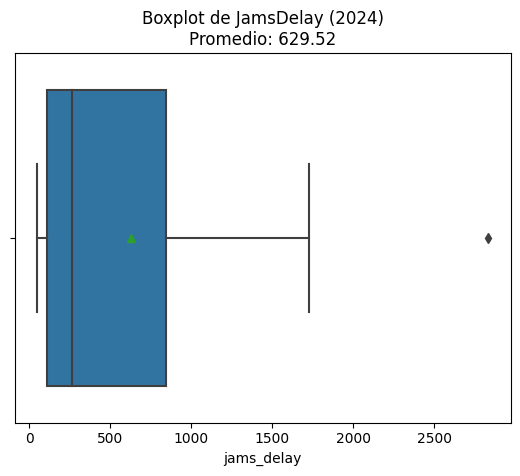

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(x=merged['jams_delay'], showmeans=True)


# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


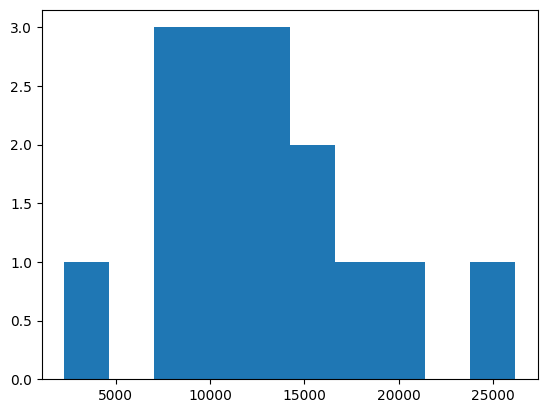

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.hist(merged['city_gdp_capita'])
plt.show()

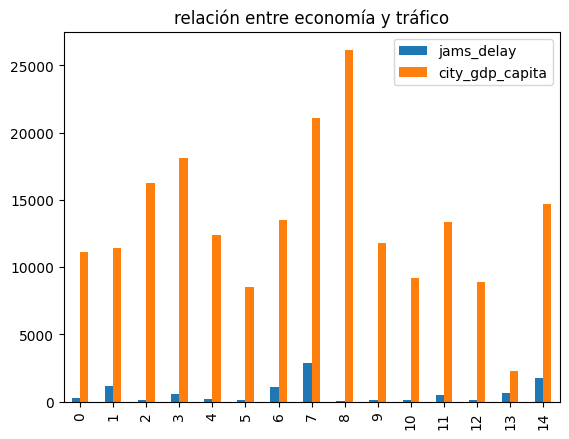

In [18]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind='bar',y=['jams_delay', 'city_gdp_capita'])
plt.title('relación entre economía y tráfico')
plt.xticks(rotation=90)
plt.show()

El análisis no muestra un patrón consistente entre el PIB per cápita y la congestión del tráfico.

In [19]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---


# 🧾 Resumen ejecutivo


**Contexto & objetivo:**  
- **¿Qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?**
  
    El análisis muestra que la relación entre la movilidad urbana y la productividad económica es débil. Aunque algunas ciudades con un mayor PIB per cápita presentan altos niveles de         congestión y tiempos de viaje elevados, no se observa una tendencia consistente que indique que un mayor desarrollo económico implique necesariamente una mejor movilidad.
  
- **Variables clave utilizadas y su relevancia para la toma de decisiones**

    Se utilizaron indicadores de movilidad como **jams_delay**, **traffic_index_live** y **travel_time_live_per_10kms_mins**, junto con **city_gdp_capita** como indicador de                   productividad económica. Estas variables permiten identificar ciudades donde la congestión podría afectar la eficiencia del transporte y servir como apoyo para la planificación            urbana, la priorización de inversiones en infraestructura y el diseño de políticas de movilidad.

**Cobertura de datos:**  
- **Años analizados**
    Se analizaron datos correspondientes al año **2024**.
  
- **Número de ciudades y países incluidos**
    El conjunto de datos incluye **15 ciudades** de **7 países** de América Latina.

**Metodología:**  
- **Limpieza de datos**
    Se estandarizaron formatos, se corrigieron tipos de datos y se verificó la consistencia de las columnas antes del análisis.
- **Integración de la información**
    Los datos fueron agregados por ciudad y año para obtener valores promedio y posteriormente se unieron mediante una unión **INNER** entre la base de movilidad y la base económica.
- **Validaciones visuales**
    Se emplearon histogramas, diagramas de caja y gráficos comparativos para evaluar distribuciones, detectar valores atípicos e identificar tendencias generales.

**Hallazgos iniciales:**  
- **Patrones entre tráfico y PIB per cápita**
    Los resultados indican una relación débil entre los indicadores de congestión y el PIB per cápita, sin evidenciar una asociación lineal clara entre ambas variables.
- **Anomalías u outliers**
    Se identificaron ciudades con niveles de congestión significativamente superiores al resto de la muestra, las cuales podrían requerir un análisis específico para comprender los            factores que explican su comportamiento.

**Recomendaciones**  

- **Bogotá** presenta uno de los niveles de congestión más altos (**jams_delay ≈ 1142**) y un PIB per cápita relativamente bajo (**city_gdp_capita ≈ 11 442**), por lo que destaca como la      ciudad que mejor representa esa combinación.
- **Lima** también registra una congestión muy elevada (**jams_delay ≈ 1052**), pero su PIB per cápita es ligeramente superior (**city_gdp_capita ≈ 13 472**).
- **Buenos Aires** presenta una congestión menor (**jams_delay ≈ 571**) y un PIB per cápita considerablemente más alto (**city_gdp_capita ≈ 18 117**), por lo que no encaja tan claramente      en ese perfil.
  
    Además, aunque **Ciudad de México** y **São Paulo** registran los mayores niveles de congestión del conjunto de datos, sus PIB per cápita no son los más bajos, por lo que no reflejan      la combinación de **alta congestión y baja productividad económica**.
  
    Por lo tanto, con la información disponible, **Bogotá** sería la ciudad prioritaria para considerar inversiones en infraestructura de transporte, ya que combina un nivel de congestión     muy elevado con un PIB per cápita inferior al de otras ciudades con problemas similares. No obstante, esta conclusión debe interpretarse como una **comparación descriptiva** y no como     una correlación estadística, dado que el análisis se basa únicamente en datos del año 2024.



